# London House Price Prediction Model Training
This notebook trains several regression models on `dataset/London.csv`, evaluates them,
and exports the best model plus preprocessing artifacts to the `models/` folder for the
Flask app to consume. Run cells from top to bottom (Run All).

In [1]:
# 0. Imports
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib

# Optional import: xgboost (if available)
try:
    import xgboost as xgb
    _HAS_XGB = True
except Exception:
    _HAS_XGB = False

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

In [2]:
# 1. Load dataset
data_path = 'dataset/London.csv'
assert os.path.exists(data_path), f'Dataset not found: {data_path}'
df = pd.read_csv(data_path, index_col=0)
print('Loaded dataset with shape:', df.shape)
df.head()

Loaded dataset with shape: (3480, 10)


,Property Name,Price,House Type,Area in sq ft,No. of Bedrooms,No. of Bathrooms,No. of Receptions,Location,City/County,Postal Code
0,Queens Road,1675000,House,2716,5,5,5,Wimbledon,London,SW19 8NY
1,Seward Street,650000,Flat / Apartment,814,2,2,2,Clerkenwell,London,EC1V 3PA
2,Hotham Road,735000,Flat / Apartment,761,2,2,2,Putney,London,SW15 1QL
3,Festing Road,1765000,House,1986,4,4,4,Putney,London,SW15 1LP
4,Spencer Walk,675000,Flat / Apartment,700,2,2,2,Putney,London,SW15 1PL


In [3]:
# 2. Preprocessing: clean and encode basic categorical columns
df_clean = df.copy()
# Drop obviously non-predictive columns if present
for c in ['Property Name', 'Postal Code']:
    if c in df_clean.columns:
        df_clean = df_clean.drop(columns=[c])

# Fill missing values for Location/City with 'Unknown' and drop rows missing target/features
for c in ['Location', 'City/County']:
    if c in df_clean.columns:
        df_clean[c] = df_clean[c].fillna('Unknown')

# Ensure required numeric columns exist
required = ['Price', 'Area in sq ft', 'No. of Bedrooms']
for c in required:
    assert c in df_clean.columns, f'Missing required column: {c}'

df_clean = df_clean.dropna(subset=['Price', 'Area in sq ft', 'No. of Bedrooms'])

# Create/ensure categorical columns exist
for c in ['House Type', 'Location', 'City/County']:
    if c not in df_clean.columns:
        df_clean[c] = 'Unknown'

# Encode categories with LabelEncoder (store encoders)
le_house_type = LabelEncoder()
le_location = LabelEncoder()
le_city = LabelEncoder()

df_clean['House Type Encoded'] = le_house_type.fit_transform(df_clean['House Type'].astype(str))
df_clean['Location Encoded'] = le_location.fit_transform(df_clean['Location'].astype(str))
df_clean['City/County Encoded'] = le_city.fit_transform(df_clean['City/County'].astype(str))

print('Preprocessing complete — dataset shape:', df_clean.shape)

Preprocessing complete — dataset shape: (3480, 11)


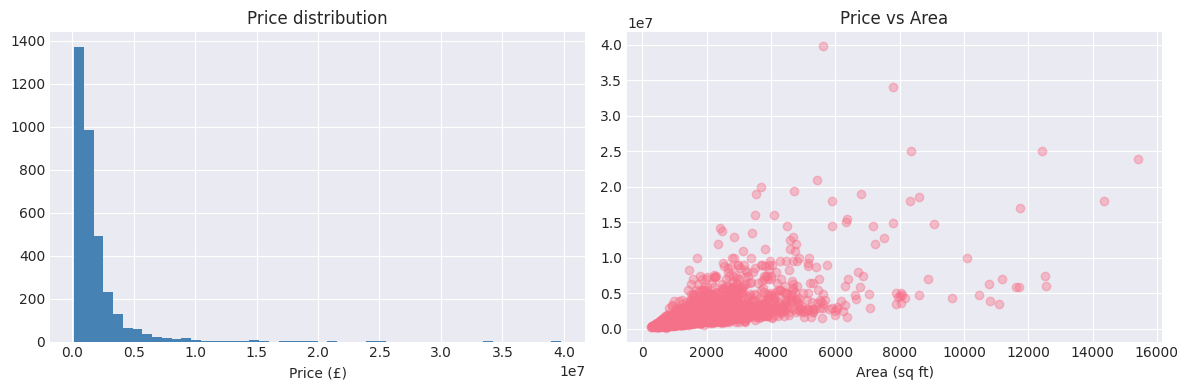

In [4]:
# 3. Exploratory plots (quick)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df_clean['Price'], bins=50, color='steelblue')
axes[0].set_title('Price distribution')
axes[0].set_xlabel('Price (£)')
axes[1].scatter(df_clean['Area in sq ft'], df_clean['Price'], alpha=0.4)
axes[1].set_title('Price vs Area')
axes[1].set_xlabel('Area (sq ft)')
plt.tight_layout()
plt.show()

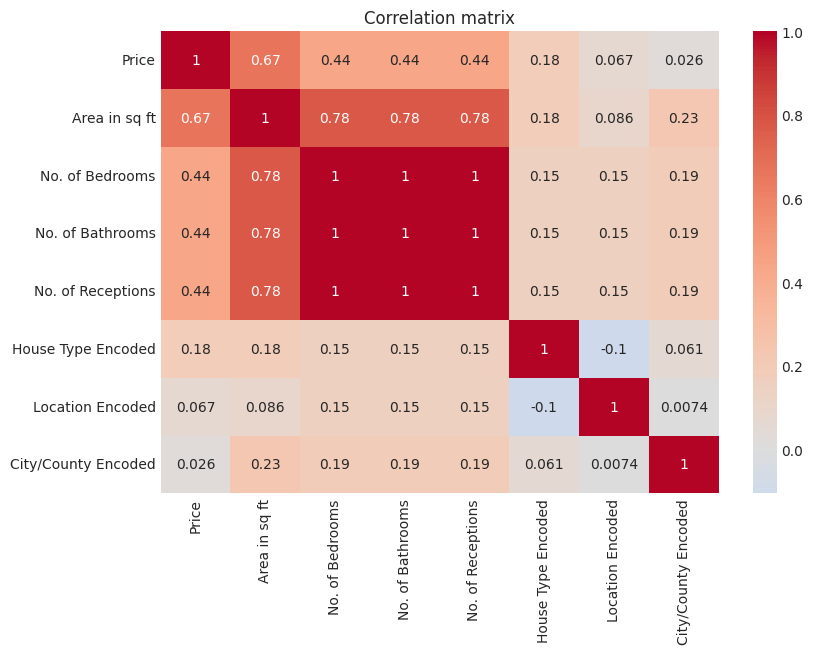

In [5]:
# 4. Correlation heatmap
num_cols = ['Price', 'Area in sq ft', 'No. of Bedrooms', 'No. of Bathrooms', 'No. of Receptions',
            'House Type Encoded', 'Location Encoded', 'City/County Encoded']
num_cols = [c for c in num_cols if c in df_clean.columns]
corr = df_clean[num_cols].corr()
plt.figure(figsize=(9, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation matrix')
plt.show()

In [6]:
# 5. Prepare features and split
feature_cols = [c for c in ['Area in sq ft', 'No. of Bedrooms', 'No. of Bathrooms', 'No. of Receptions',
                             'House Type Encoded', 'Location Encoded', 'City/County Encoded'] if c in df_clean.columns]
X = df_clean[feature_cols]
y = df_clean['Price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print('Train size:', X_train.shape[0], 'Test size:', X_test.shape[0])

Train size: 2784 Test size: 696


In [7]:
# 6. Train simple models
models = {}
# Linear Regression (uses scaled features)
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
models['Linear Regression'] = lr
# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
models['Random Forest'] = rf
# Gradient Boosting
gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)
models['Gradient Boosting'] = gb
# XGBoost if available
if _HAS_XGB:
    xg = xgb.XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    xg.fit(X_train, y_train)
    models['XGBoost'] = xg

print('Trained models:', list(models.keys()))

Trained models: ['Linear Regression', 'Random Forest', 'Gradient Boosting', 'XGBoost']


In [8]:
# 7. Evaluate models and pick best by Test R²
results = []
for name, m in models.items():
    if name == 'Linear Regression':
        y_pred_test = m.predict(X_test_scaled)
    else:
        y_pred_test = m.predict(X_test)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    test_mae = mean_absolute_error(y_test, y_pred_test)
    test_r2 = r2_score(y_test, y_pred_test)
    results.append({'model': name, 'test_rmse': test_rmse, 'test_mae': test_mae, 'test_r2': test_r2})
results_df = pd.DataFrame(results).sort_values(by='test_r2', ascending=False).reset_index(drop=True)
results_df
best_model_name = results_df.loc[0, 'model']
best_model = models[best_model_name]
print(f"Best model: {best_model_name} (Test R²={results_df.loc[0, 'test_r2']:.4f})")

Best model: Gradient Boosting (Test R²=0.6609)


In [9]:
# 8. Optional: quick hyperparameter tuning for Random Forest (if it's best)
tuned_model = None
if best_model_name == 'Random Forest':
    param_dist = {'n_estimators': [50, 100, 200], 'max_depth': [10, 20, None], 'min_samples_split': [2, 5]}
    rs = RandomizedSearchCV(models['Random Forest'], param_dist, n_iter=6, cv=3, scoring='r2', n_jobs=-1, random_state=42)
    rs.fit(X_train, y_train)
    tuned_model = rs.best_estimator_
    print('RandomizedSearchCV best params:', rs.best_params_)
    # evaluate
    y_pred_tuned = tuned_model.predict(X_test)
    print('Tuned RF Test R2:', r2_score(y_test, y_pred_tuned))
else:
    print('Skipping tuning (best model not Random Forest)')

Skipping tuning (best model not Random Forest)


In [10]:
# 9. Export the chosen model and preprocessing artifacts
os.makedirs('models', exist_ok=True)
# choose final model (tuned if available)
if tuned_model is not None:
    final_model = tuned_model
else:
    final_model = best_model
# Save model (note: LinearRegression expects scaled features)
joblib.dump(final_model, 'models/house_price_model.pkl')
joblib.dump(scaler, 'models/scaler.pkl')
joblib.dump({'le_house_type': le_house_type, 'le_location': le_location, 'le_city': le_city}, 'models/encoders.pkl')
with open('models/feature_info.json', 'w') as f:
    json.dump({'features': feature_cols, 'best_model': best_model_name}, f, indent=2)
print('Exported model and artifacts to models/ directory')

Exported model and artifacts to models/ directory


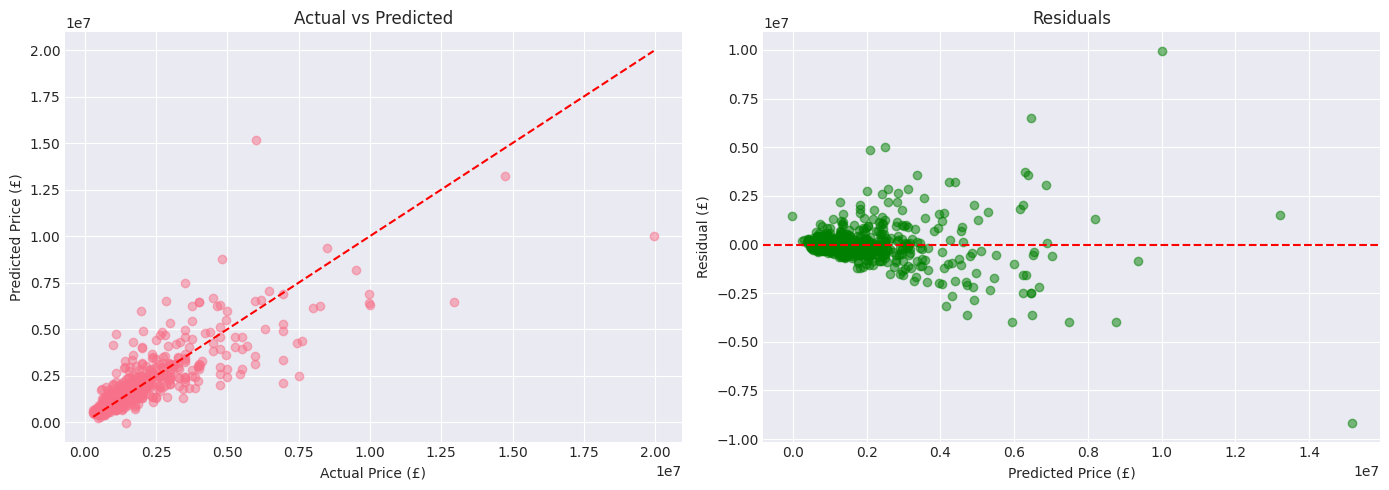

In [11]:
# 10. Final visualization: Actual vs Predicted (uses final_model)
if isinstance(final_model, LinearRegression):
    Xp = X_test_scaled
else:
    Xp = X_test
y_pred = final_model.predict(Xp)
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].scatter(y_test, y_pred, alpha=0.5)
ax[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
ax[0].set_title('Actual vs Predicted')
ax[0].set_xlabel('Actual Price (£)')
ax[0].set_ylabel('Predicted Price (£)')
res = y_test - y_pred
ax[1].scatter(y_pred, res, alpha=0.5, color='green')
ax[1].axhline(0, color='r', ls='--')
ax[1].set_title('Residuals')
ax[1].set_xlabel('Predicted Price (£)')
ax[1].set_ylabel('Residual (£)')
plt.tight_layout()
plt.show()